In [1]:
import pandas as pd
user_concentration_df = pd.read_csv(r"D:\내 자료실(이동,삭제 절대금지~~!!)\Desktop\data analysis\Proj_1 e_cummerce\Python\user_concentration.csv")

In [2]:
user_concentration_df.head()

,user_id,category_cnt,product_cnt,event_cnt,purchase_flag,purchase_category_cnt
0,10300217,1,1,1,0,0
1,29515875,2,5,11,0,0
2,31198833,3,18,20,0,0
3,34916060,1,1,1,0,0
4,41798457,1,1,1,0,0


In [3]:
# 카테고리 수에 따른 구매의사 보정치

user_concentration_df["purchase_flag_c"]=user_concentration_df["purchase_category_cnt"]/user_concentration_df["category_cnt"]

In [4]:
# 카테고리 내, 상품당 event 발생수

user_concentration_df["concentration"]=user_concentration_df["event_cnt"]/user_concentration_df["product_cnt"]

In [5]:
# concentration 반올림

user_concentration_df["concentration_round"] = (
    user_concentration_df["concentration"]
      .round(0)
      .astype(int)
)

In [6]:
# concentration 극단 조사

user_concentration_df["concentration_round"].quantile([0.99,0.995,0.999])

0.990     6.0
0.995     8.0
0.999    13.0
Name: concentration_round, dtype: float64

In [7]:
pd.set_option("display.max_rows",50)

In [8]:
# concentration 이상치 조사

user_concentration_df["concentration_round"].value_counts().sort_index(ascending=True).head(50)

concentration_round
1     1854401
2     1234710
3      338511
4      155486
5       46725
6       28404
7       11910
8        8984
9        4368
10       3583
11       1826
12       1628
13        924
14        881
15        523
16        455
17        291
18        272
19        192
20        190
21        110
22        110
23         90
24         72
25         44
26         56
27         36
28         35
29         32
30         34
31         14
32         23
33         17
34         17
35          9
36          8
37         15
38         10
39          8
40         10
41          6
42         12
43          6
44          4
45          3
46          4
47          4
48          5
49          2
50          1
Name: count, dtype: int64

In [9]:
# 그래프 그리기 위한 임시 프레임

tmp = (user_concentration_df.groupby("concentration_round")["purchase_flag_c"]
      .mean().reset_index())

In [10]:
tmp = tmp[tmp["concentration_round"] <= 13]

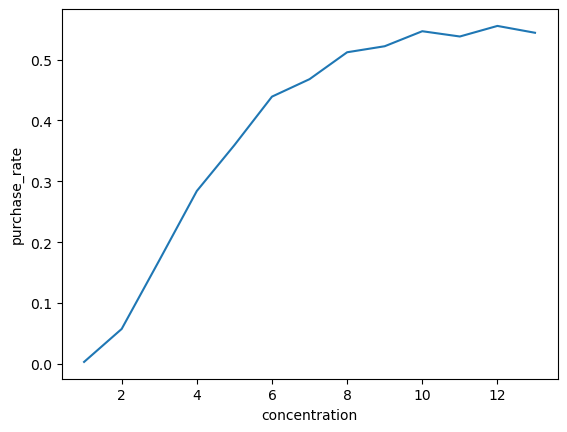

In [11]:
# 집중도와 구매의사비율 관계

import matplotlib.pyplot as plt

plt.plot(
    tmp["concentration_round"],
    tmp["purchase_flag_c"]
)

plt.xlabel("concentration")
plt.ylabel("purchase_rate")

plt.show()